#Mounting and data setup (for Tomas)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# For TOMAS
data = '/content/drive/MyDrive/PimaIndiansDiabetesDatabase.csv'

In [ ]:
import pandas as pd

data_pre = pd.read_csv(data)

In [ ]:
cols = data_pre.columns
print("---- This data uses a combination of supervised learning and non-age specific generalisation ----")
print(cols)
print(data_pre.shape)
print(f"Shape of young data: {data_pre[data_pre['Age'] < 29].shape}")
print(f"Shape of old data: {data_pre[data_pre['Age'] >= 29].shape}")
print(f"Max age: {max(data_pre['Age'])}")
print(f"Min age: {min(data_pre['Age'])}")

---- This data uses a combination of supervised learning and non-age specific generalisation ----
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
(768, 9)
Shape of young data: (367, 9)
Shape of old data: (401, 9)
Max age: 81
Min age: 21


#Mounting and data setup (for others)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#
data_ = '/content/drive/MyDrive/datathon/Pima Indians Diabetes Database.csv'

In [ ]:
data = '/content/drive/MyDrive/bmet2925 datathon team/Pima Indians Diabetes Database.csv'

In [ ]:
import pandas as pd

data_pre = pd.read_csv(data)

In [ ]:
cols = data_pre.columns
print("---- This data uses a combination of supervised learning and non-age specific generalisation ----")
print(cols)
print(data_pre.shape)
print(f"Shape of young data: {data_pre[data_pre['Age'] < 29].shape}")
print(f"Shape of old data: {data_pre[data_pre['Age'] >= 29].shape}")
print(f"Max age: {max(data_pre['Age'])}")
print(f"Min age: {min(data_pre['Age'])}")

---- This data uses a combination of supervised learning and non-age specific generalisation ----
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
(768, 9)
Shape of young data: (367, 9)
Shape of old data: (401, 9)
Max age: 81
Min age: 21


#Data Cleaning#

Dataset Shape: (768, 9)

 Column Data Types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

 Null Values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

 Summary Statistics:
        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.

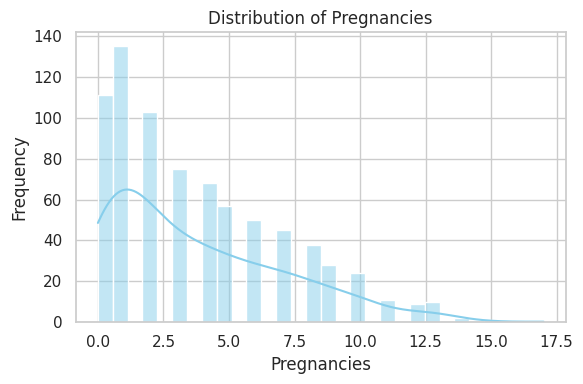

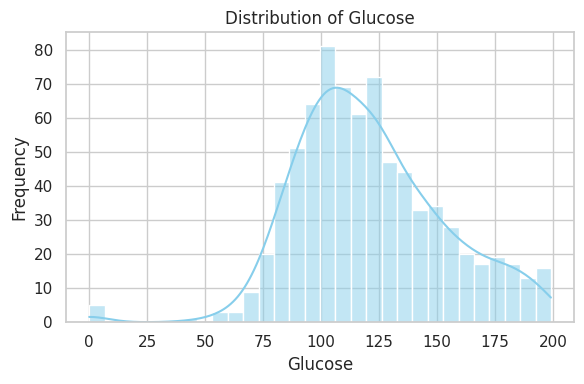

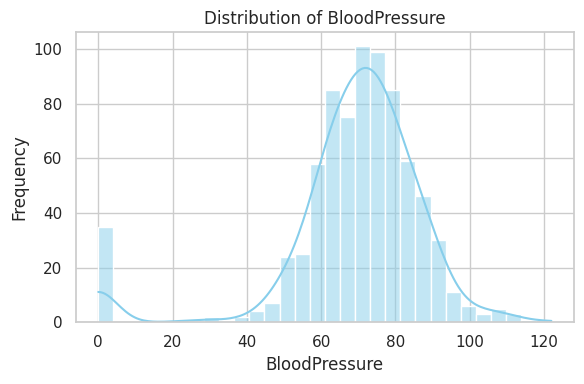

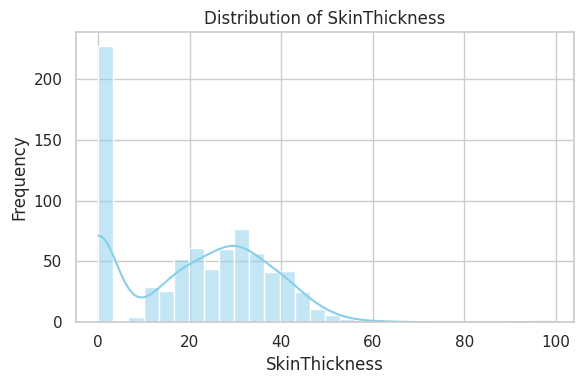

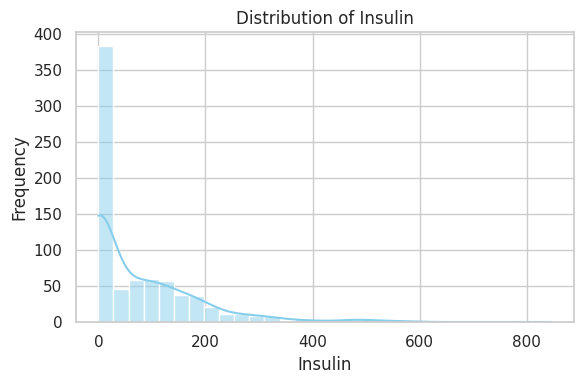

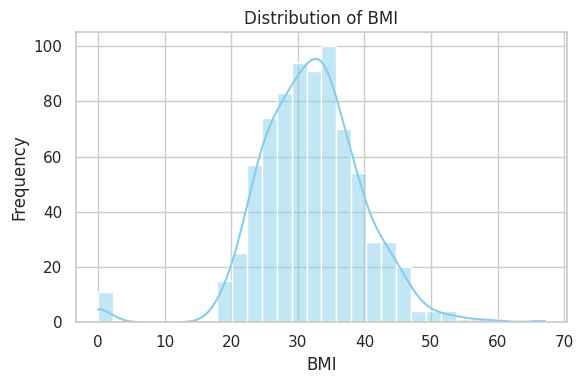

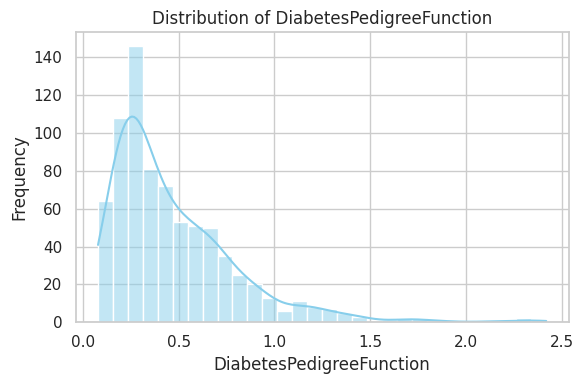

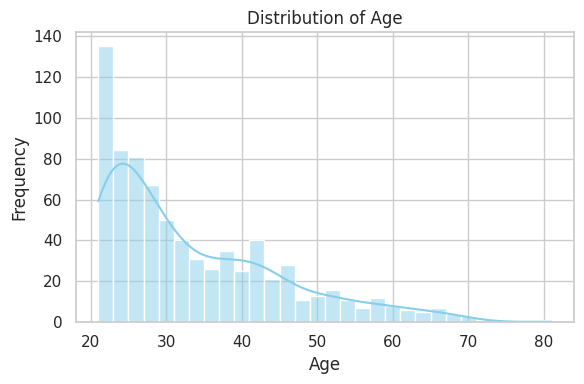

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv(data)

# Display basic info
print("Dataset Shape:", data.shape)
print("\n Column Data Types:\n", data.dtypes)
print("\n Null Values:\n", data.isnull().sum())
print("\n Summary Statistics:\n", data.describe())


# Set style
sns.set(style="whitegrid")

# 1. Distribution plots for each feature
numerical_cols = data.columns.drop('Outcome')
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()




In [ ]:

data_pre = '/content/drive/MyDrive/datathon/Cleaned_Dataset.csv'
data_pre = pd.read_csv(data_pre)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/datathon/Cleaned_Dataset.csv'

In [ ]:
#Doesn't work due to tuple?

# age is good
# pregnancies is good (because of region data is from)
# glucose - skewed - replace zeros with median
# blood pressure - below 40 replace with mean
# skin thickness - more than 64 or below 9 --> replace with mean
# insulin - at 0 replace with median
# BMI - above 54 and at 0 replace with mean
# diabetes pedigree function is good

import pandas as pd

# 1. Glucose: replace zeros with median (as integer)
glucose_median = int(data_pre['Glucose'].median())
data_pre['Glucose'] = data_pre['Glucose'].replace(0, glucose_median)
data_pre['Glucose'] = data_pre['Glucose'].astype(int)

# 2. Blood Pressure: below 40 replace with mean (as integer)
bp_mean = int(data_pre['BloodPressure'].mean())
data_pre.loc[data_pre['BloodPressure'] < 40, 'BloodPressure'] = bp_mean
data_pre['BloodPressure'] = data_pre['BloodPressure'].astype(int)

# 3. Skin Thickness: more than 64 or below 9 → replace with mean (as integer)
skin_thickness_mean = int(data_pre['SkinThickness'].mean())
data_pre.loc[(data_pre['SkinThickness'] > 64) | (data_pre['SkinThickness'] < 9), 'SkinThickness'] = skin_thickness_mean
data_pre['SkinThickness'] = data_pre['SkinThickness'].astype(int)

# 4. Insulin: replace zeros with median (as integer)
insulin_median = int(data_pre['Insulin'].median())
data_pre['Insulin'] = data_pre['Insulin'].replace(0, insulin_median)
data_pre['Insulin'] = data_pre['Insulin'].astype(int)

# 5. BMI: replace above 54 and at 0 with mean (rounded to 1 decimal place)
bmi_mean = round(data_pre['BMI'].mean(), 1)
data_pre.loc[(data_pre['BMI'] > 54) | (data_pre['BMI'] == 0), 'BMI'] = bmi_mean
data_pre['BMI'] = data_pre['BMI'].round(1)

# Optional: Save the cleaned dataset
data_pre.to_csv('Cleaned_Dataset.csv', index=False)

# Show the first few rows
print(data_pre.head())
print(data_pre.shape())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35       30  33.6   
1            1       85             66             29       30  26.6   
2            8      183             64             20       30  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


TypeError: 'tuple' object is not callable

#Explortary Data Analysis

Dataset Shape: (768, 9)

 Column Data Types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

 Null Values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

 Summary Statistics:
        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.

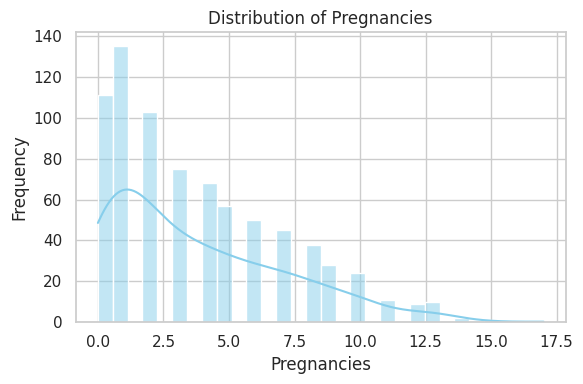

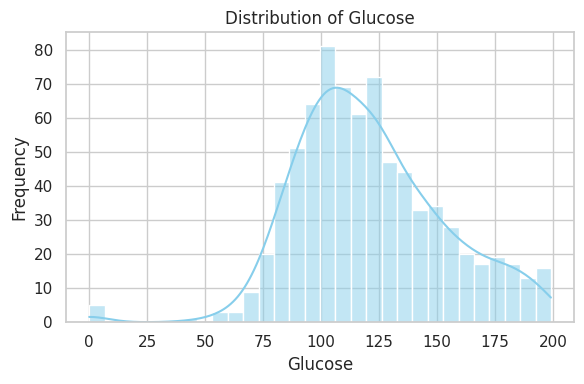

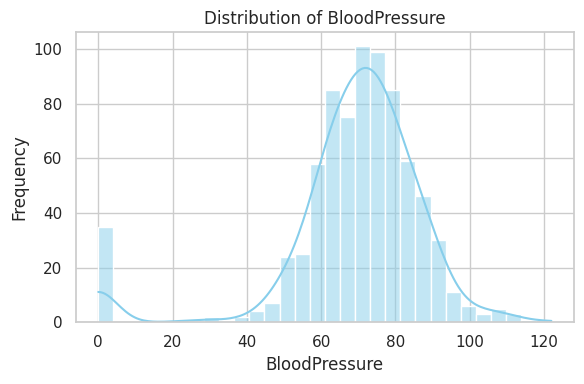

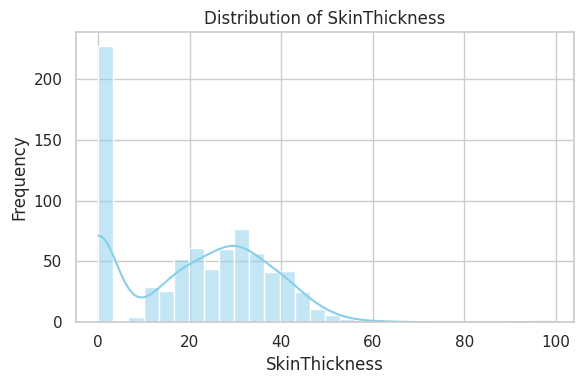

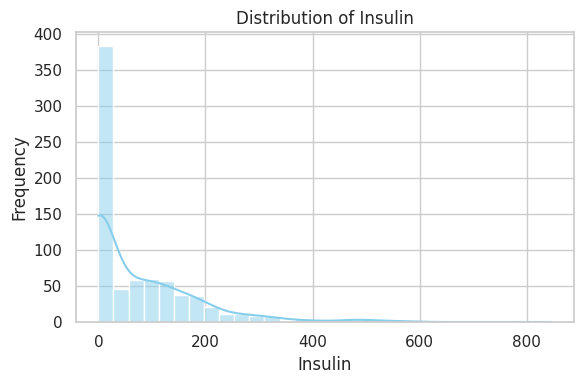

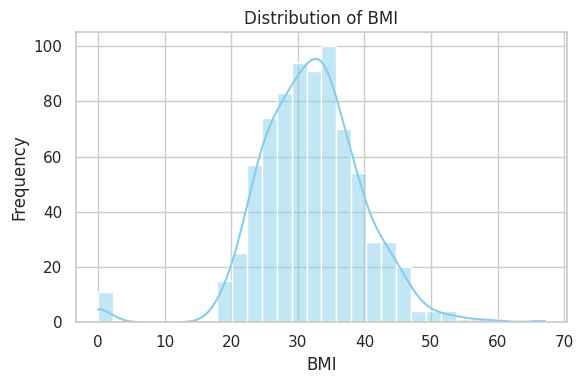

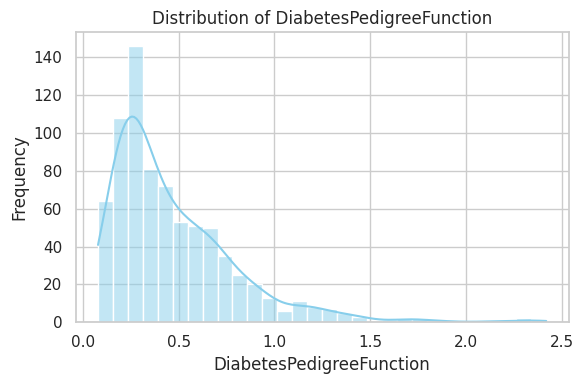

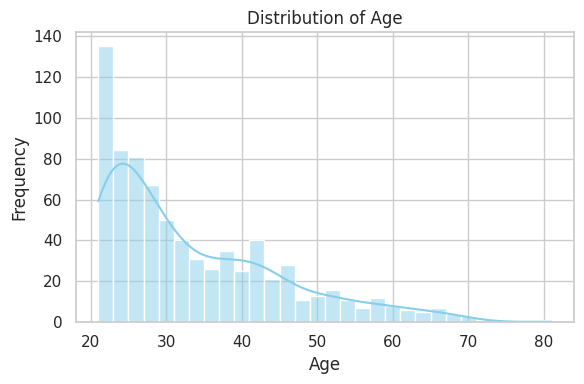

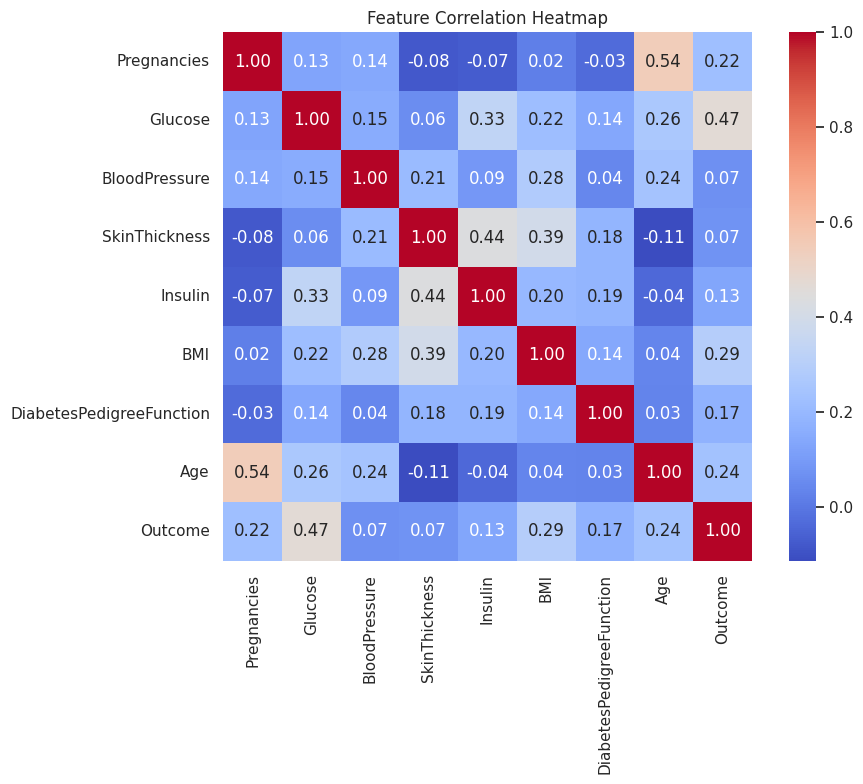

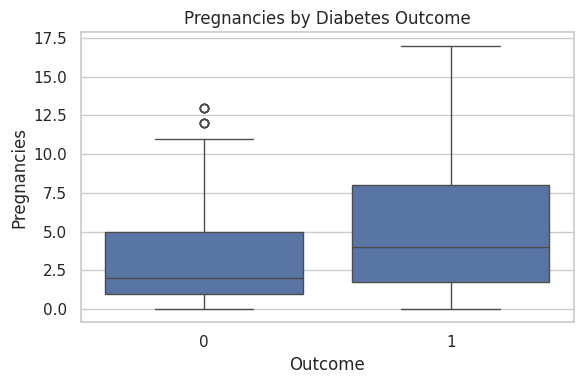

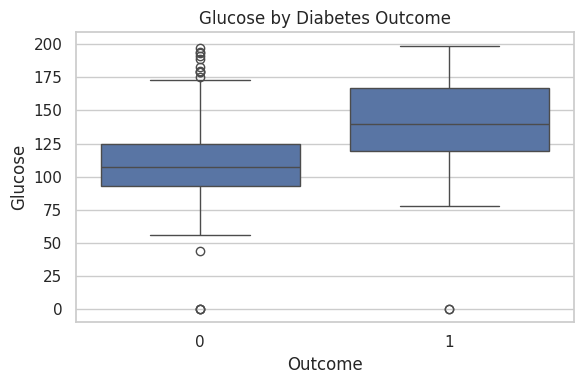

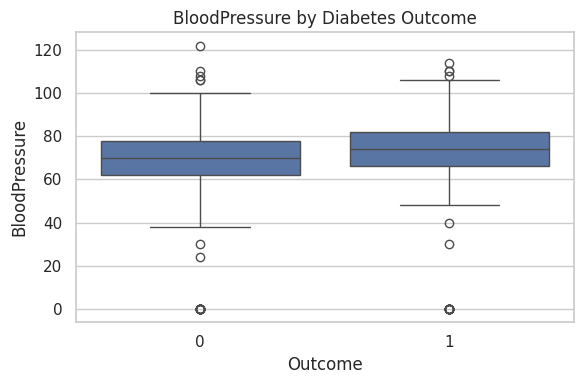

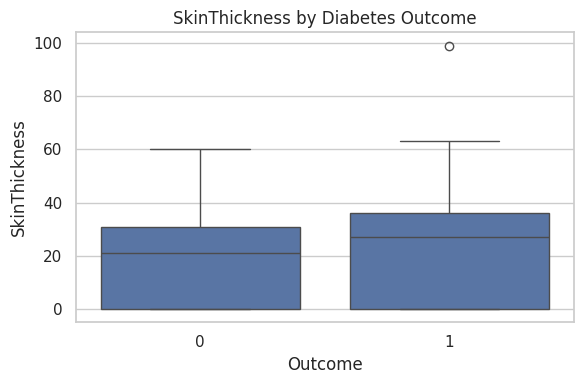

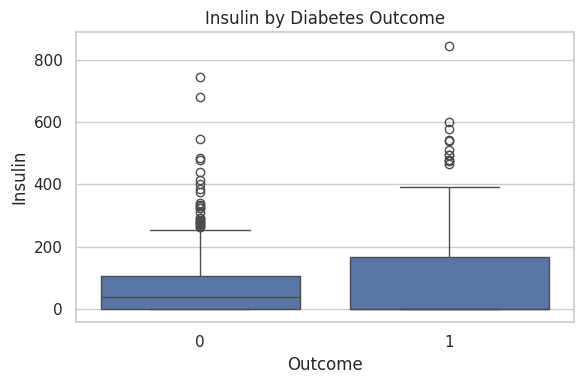

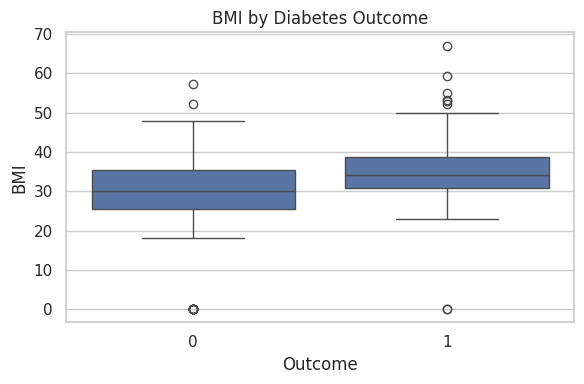

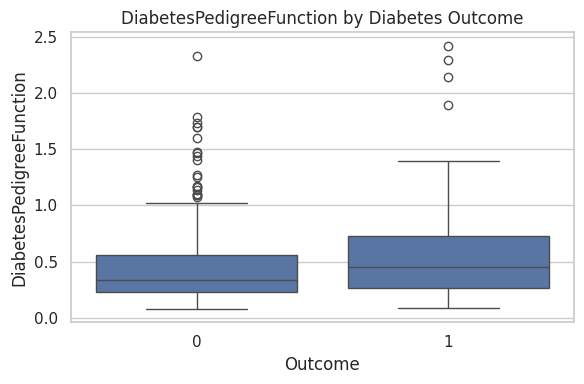

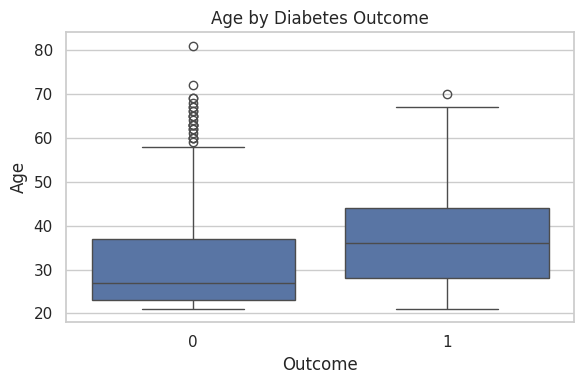

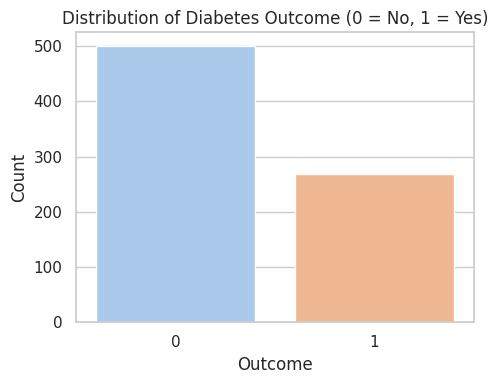

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
#data_pre = pd.read_csv('Cleaned_Dataset.csv')

# Display basic info
print("Dataset Shape:", data_pre.shape)
print("\n Column Data Types:\n", data_pre.dtypes)
print("\n Null Values:\n", data_pre.isnull().sum())
print("\n Summary Statistics:\n", data_pre.describe())


# Set style
sns.set(style="whitegrid")

# 1. Distribution plots for each feature
numerical_cols = data_pre.columns.drop('Outcome')
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data_pre[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = data_pre.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# 3. Boxplots of each feature grouped by Outcome
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Outcome', y=col, data=data_pre)
    plt.title(f'{col} by Diabetes Outcome')
    plt.tight_layout()
    plt.show()

# 4. Outcome Class Balance
plt.figure(figsize=(5, 4))
sns.countplot(x='Outcome', data=data_pre, hue='Outcome', palette='pastel', legend=False)
plt.title('Distribution of Diabetes Outcome (0 = No, 1 = Yes)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


#Model evaluations:

In [ ]:
#============================================================================================
# Plotting ROC curves to compare performance of 12 models (1a to 6b)
#============================================================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Define model names and corresponding variables
model_ids = ['1a', '1b', '2a', '2b', '3a', '3b', '4a', '4b', '5a', '5b', '6a', '6b']
models = [model_1a, model_1b, model_2a, model_2b, model_3a, model_3b,
          model_4a, model_4b, model_5a, model_5b, model_6a, model_6b]
X_tests = [X_test_old, X_test_young, X_test_young_1, X_test_old_1, X_test_young_2, X_test_young_2,
           X_test_old, X_test_young, X_test_young_1, X_test_old_1, X_test_young_2, X_test_young_2]
y_tests = [y_test_old, y_test_young, y_test_young_1, y_test_old_1, y_test_young_2, y_test_young_2,
           y_test_old, y_test_young, y_test_young_1, y_test_young_1, y_test_young_2, y_test_young_2]

# Set up the plot
plt.figure(figsize=(10, 8))

# Loop through and plot each model's ROC curve
for model_id, model, X_test, y_test in zip(model_ids, models, X_tests, y_tests):
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Model {model_id} (AUC = {roc_auc:.3f})')
    except Exception as e:
        print(f"Error with model {model_id}: {e}")

# Plot random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Chart formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison for Models 1a to 6b')
plt.legend(loc="lower right", fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'model_1a' is not defined

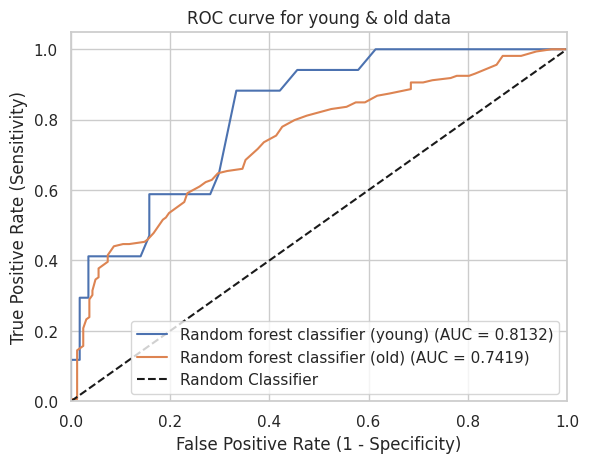

In [ ]:
#============================================================================================
# Plotting ROC curve to compare models performances (young & old data)
#============================================================================================

# install required packages
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_prob_young = model_1a.predict_proba(X_test_young)[:, 1]

# Get predicted probabilities for the positive class (class 1)
y_prob_old = model_1b.predict_proba(X_test_old)[:, 1]

# Compute ROC curve and AUC
fpr_young, tpr_young, thresholds_young = roc_curve(y_test_young, y_prob_young)
roc_auc_young = auc(fpr_young, tpr_young)

# Compute ROC curve and AUC
fpr_old, tpr_old, thresholds_old = roc_curve(y_test_old, y_prob_old)
roc_auc_old = auc(fpr_old, tpr_old)

# Plot ROC curve
plt.figure()
plt.plot(fpr_young, tpr_young, label=f'Random forest classifier (young) (AUC = {roc_auc_young:.4f})')
plt.plot(fpr_old, tpr_old, label=f'Random forest classifier (old) (AUC = {roc_auc_old:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC curve for young & old data')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

In [ ]:
#Thresholding using ROC
def thresholding(models, X_tests, y_tests, model_ids):
    thresholds = {}
    print("\nOptimal Thresholds:")
    for model_id, model, X_test, y_test in zip(model_ids, models, X_tests, y_tests):
        try:
            y_prob = model.predict_proba(X_test)[:, 1]
            fpr, tpr, thresholds_list = roc_curve(y_test, y_prob)
            j_scores = tpr - fpr
            optimal_idx = np.argmax(j_scores)
            optimal_threshold = thresholds_list[optimal_idx]
            thresholds[model_id] = (optimal_threshold, y_prob, y_test)
            print(f"Model {model_id}: Optimal Threshold = {optimal_threshold:.4f}")
        except Exception as e:
            print(f"Error with model {model_id}: {e}")
    return thresholds

In [ ]:
def evaluate_models(thresholds_dict):
    print("\nEvaluation Metrics at Optimal Thresholds:")
    for model_id, (threshold, y_prob, y_test) in thresholds_dict.items():
        y_pred = (y_prob >= threshold).astype(int)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        print(f"\nModel {model_id}:")
        print(f"  Accuracy : {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall   : {rec:.4f}")
        print(f"  F1 Score : {f1:.4f}")

# --- Call the functions after your ROC plotting code ---
thresholds_dict = thresholding(models, X_tests, y_tests, model_ids)
evaluate_models(thresholds_dict)


Optimal Thresholds:
Model 1a: Optimal Threshold = 0.4800
Model 1b: Optimal Threshold = 0.0900
Model 2a: Optimal Threshold = 0.3700
Model 2b: Optimal Threshold = 0.5200
Model 3a: Optimal Threshold = 0.2800
Model 3b: Optimal Threshold = 0.1200
Model 4a: Optimal Threshold = 1.0000
Model 4b: Optimal Threshold = 1.0000
Model 5a: Optimal Threshold = 1.0000
Error with model 5b: Found input variables with inconsistent numbers of samples: [74, 81]
Model 6a: Optimal Threshold = 1.0000
Model 6b: Optimal Threshold = 1.0000

Evaluation Metrics at Optimal Thresholds:

Model 1a:
  Accuracy : 0.7165
  Precision: 0.7099
  Recall   : 0.7233
  F1 Score : 0.7165

Model 1b:
  Accuracy : 0.6757
  Precision: 0.4103
  Recall   : 0.9412
  F1 Score : 0.5714

Model 2a:
  Accuracy : 0.8243
  Precision: 0.6667
  Recall   : 0.4706
  F1 Score : 0.5517

Model 2b:
  Accuracy : 0.7037
  Precision: 0.7179
  Recall   : 0.6829
  F1 Score : 0.7000

Model 3a:
  Accuracy : 0.8028
  Precision: 0.5000
  Recall   : 0.7143
  F1

# Model Formation

Below is the code for the **splitting** of the data into young/old sections

In [ ]:
#============================================================================================
# Splitting model into old & young data
#============================================================================================

# Clean data
data_clean = data_pre.dropna()

# Define features and target
feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
target_col = 'Outcome'

# Split data by age
young_data = data_clean[data_clean['Age'] < 29]
old_data = data_clean[data_clean['Age'] >= 29]

# load required packages
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

#============================================================================================
# Splitting for young training
#============================================================================================

# Further split old_data: fine-tune (20%), final test (80%)
old_finetune_20, old_test_80 = train_test_split(old_data, test_size=0.80, random_state=42)

# Split young_data: train (60%), finetune_test (40%)
young_train_60, young_finetune_test_40 = train_test_split(young_data, test_size=0.40, random_state=42)

# Split young_finetune_test_40: fine_tune (20%), test (20%) : 50-50
young_finetune_20, young_test_20 = train_test_split(young_finetune_test_40, test_size=0.50, random_state=42)

# Define train/test splits
X_train = young_train_60[feature_cols]
y_train = young_train_60[target_col]
X_finetune_old = old_finetune_20[feature_cols]
y_finetune_old = old_finetune_20[target_col]
X_test_old = old_test_80[feature_cols]
y_test_old = old_test_80[target_col]
X_finetune_young = young_finetune_20[feature_cols]
y_finetune_young = young_finetune_20[target_col]
X_test_young = young_test_20[feature_cols]
y_test_young = young_test_20[target_col]

#============================================================================================
# Splitting for old training
#============================================================================================

# Further split young_data: fine-tune (20%), final test (80%)
young_finetune_20, young_test_80 = train_test_split(young_data, test_size=0.80, random_state=42)

# Split old_data: train (60%), finetune_test (40%)
old_train_60, old_finetune_test_40 = train_test_split(old_data, test_size=0.40, random_state=42)

# Split old_finetune_test_40: fine_tune (20%), test (20%) : 50-50
old_finetune_20, old_test_20 = train_test_split(old_finetune_test_40, test_size=0.50, random_state=42)

# Define train/test splits
X_train_1 = old_train_60[feature_cols]
y_train_1 = old_train_60[target_col]
X_finetune_young_1 = young_finetune_20[feature_cols]
y_finetune_young_1 = young_finetune_20[target_col]
X_test_young_1 = young_test_20[feature_cols]
y_test_young_1 = young_test_20[target_col]
X_finetune_old_1 = old_finetune_20[feature_cols]
y_finetune_old_1 = old_finetune_20[target_col]
X_test_old_1 = old_test_20[feature_cols]
y_test_old_1 = old_test_20[target_col]

#============================================================================================
# Splitting for whole dataset: train (60%) test (40%) - 10% old_finetune, 10% old_test, 10% young_finetune, 10% young_test
#============================================================================================

# Split whole data: train (60%), test (40%)
data_train_60, data_finetune_test_40 = train_test_split(data_clean, test_size=0.40, random_state=42)

# Split data
X_train_2 = data_train_60[feature_cols]
y_train_2 = data_train_60[target_col]

# Split data by age
data_finetune_test_young = data_finetune_test_40[data_clean['Age'] < 29]
data_finetune_test_old = data_finetune_test_40[data_clean['Age'] >= 29]

# Split data_finetune_test_young: fine_tune (20%), test (20%) : 50-50
data_finetune_young_20, data_test_young_20 = train_test_split(data_finetune_test_young, test_size=0.50, random_state=42)

# Split old_test_data: fine_tune (20%), test (20%) : 50-50
data_finetune_old_20, data_test_old_20 = train_test_split(data_finetune_test_old, test_size=0.50, random_state=42)

# Define train/test splits
X_finetune_old_2 = data_finetune_old_20[feature_cols]
y_finetune_old_2 = data_finetune_old_20[target_col]
X_test_old_2 = data_test_old_20[feature_cols]
y_test_old_2 = data_test_old_20[target_col]
X_finetune_young_2 = data_finetune_young_20[feature_cols]
y_finetune_young_2 = data_finetune_young_20[target_col]
X_test_young_2 = data_test_young_20[feature_cols]
y_test_young_2 = data_test_young_20[target_col]

<ipython-input-8-22af7d78d331>:89: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_finetune_test_young = data_finetune_test_40[data_clean['Age'] < 29]
<ipython-input-8-22af7d78d331>:90: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_finetune_test_old = data_finetune_test_40[data_clean['Age'] >= 29]


Below is a function which finds the optimal threshold for a given model

In [ ]:
def get_optimal_threshold(y_true, y_prob, metric="youden"):
    thresholds = np.linspace(0, 1, 200)
    metrics = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0
        spec = tn / (tn + fp) if (tn + fp) else 0
        acc = (tp + tn) / (tp + tn + fp + fn)

        if metric == "youden":
            score = sens + spec - 1
        else:
            score = acc
        metrics.append(score)

    best_idx = np.argmax(metrics)
    return thresholds[best_idx]

def plot_threshold_performance(y_true, y_prob, model_label="Model", metric="youden", show_plot=True):
    best_threshold = get_optimal_threshold(y_true, y_prob, metric)

    y_pred = (y_prob >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    if show_plot:
        thresholds = np.linspace(0, 1, 200)
        accs, senss, specs = [], [], []
        for t in thresholds:
            y_p = (y_prob >= t).astype(int)
            tn_, fp_, fn_, tp_ = confusion_matrix(y_true, y_p).ravel()
            senss.append(tp_ / (tp_ + fn_) if (tp_ + fn_) else 0)
            specs.append(tn_ / (tn_ + fp_) if (tn_ + fp_) else 0)
            accs.append((tp_ + tn_) / (tp_ + tn_ + fp_ + fn_))

        plt.figure(figsize=(10, 6))
        plt.plot(thresholds, accs, label="Accuracy")
        plt.plot(thresholds, senss, label="Sensitivity")
        plt.plot(thresholds, specs, label="Specificity")
        plt.axvline(best_threshold, color='purple', linestyle='--', label=f'Best @ {best_threshold:.2f}')
        plt.axvline(0.5, color='grey', linestyle=':', label='Threshold = 0.5')
        plt.title(f"Threshold vs. Performance: {model_label}")
        plt.xlabel("Threshold")
        plt.ylabel("Metric Value")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    print(f"\n-------------- Best threshold for {model_label} --------------")
    print(f"Threshold: {best_threshold:.2f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print()

    return best_threshold


1 - Below is the code for the creation of a **Random Forest Classifier** model **trained on young data** which tests on old data and then tests on young data as a control.

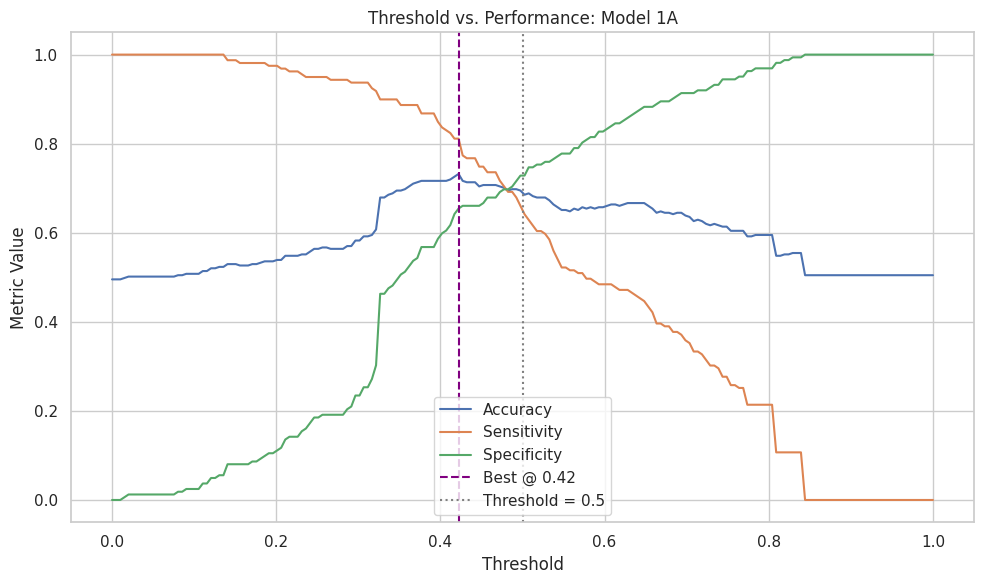


-------------- Best threshold for Model 1A --------------
Threshold: 0.42
Accuracy: 0.7321
Sensitivity: 0.8113
Specificity: 0.6543

Confusion Matrix: TP=129, TN=106, FP=56, FN=30



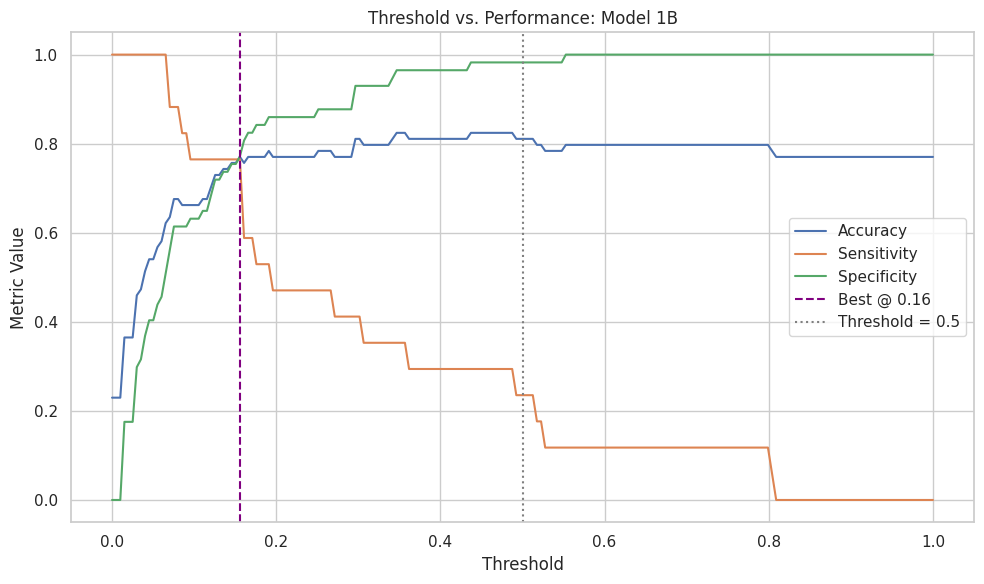


-------------- Best threshold for Model 1B --------------
Threshold: 0.16
Accuracy: 0.7703
Sensitivity: 0.7647
Specificity: 0.7719

Confusion Matrix: TP=13, TN=44, FP=13, FN=4



In [ ]:
#============================================================================================
# MODEL 1A: Train on young (60%), finetune on old (20%), test on old (80%)
#============================================================================================
base_1a = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_1a = CalibratedClassifierCV(estimator=base_1a, method='isotonic', cv=5)
model_1a.fit(pd.concat([X_train, X_finetune_old]), pd.concat([y_train, y_finetune_old]))

y_prob_1a = model_1a.predict_proba(X_test_old)[:, 1]
optimal_thresh_1a = plot_threshold_performance(y_test_old, y_prob_1a, model_label="Model 1A")

y_pred_1a = (y_prob_1a >= optimal_thresh_1a).astype(int)
tn_1a, fp_1a, fn_1a, tp_1a = confusion_matrix(y_test_old, y_pred_1a).ravel()

# Optional: print confusion matrix breakdown again
print(f"Confusion Matrix: TP={tp_1a}, TN={tn_1a}, FP={fp_1a}, FN={fn_1a}")
print()

#============================================================================================
# MODEL 1B: Train on young (60%), finetune on young (20%), test on young (20%)
#============================================================================================
base_1b = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_1b = CalibratedClassifierCV(estimator=base_1b, method='isotonic', cv=5)
model_1b.fit(pd.concat([X_train, X_finetune_young]), pd.concat([y_train, y_finetune_young]))

y_prob_1b = model_1b.predict_proba(X_test_young)[:, 1]
optimal_thresh_1b = plot_threshold_performance(y_test_young, y_prob_1b, model_label="Model 1B")

y_pred_1b = (y_prob_1b >= optimal_thresh_1b).astype(int)
tn_1b, fp_1b, fn_1b, tp_1b = confusion_matrix(y_test_young, y_pred_1b).ravel()

print(f"Confusion Matrix: TP={tp_1b}, TN={tn_1b}, FP={fp_1b}, FN={fn_1b}")
print()

2 - Below is the code for a **Random Forest Classifier** model **trained on old data**, tested on young data, and then tested as a control on old data.



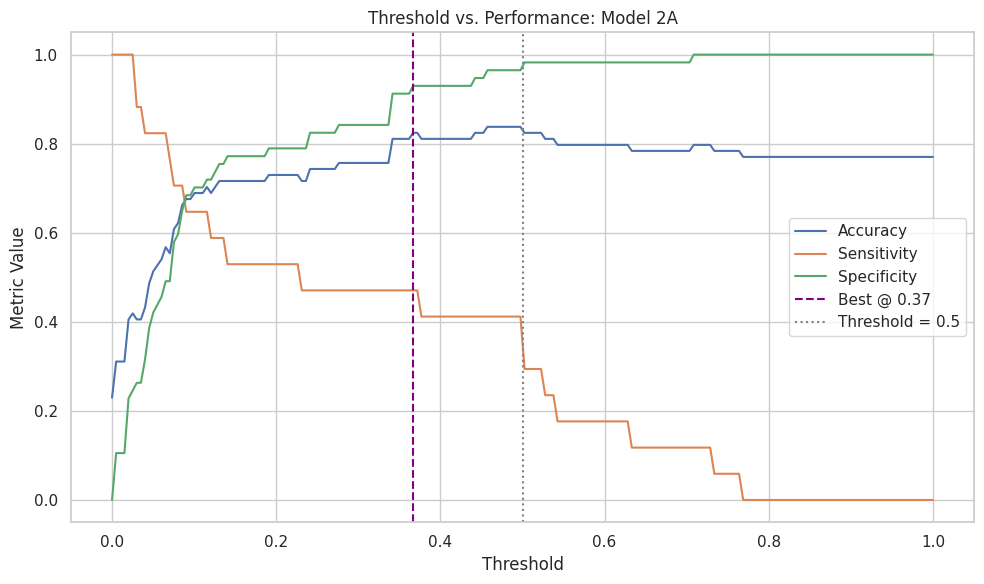


-------------- Best threshold for Model 2A --------------
Threshold: 0.37
Accuracy: 0.8243
Sensitivity: 0.4706
Specificity: 0.9298

Confusion Matrix: TP=8, TN=53, FP=4, FN=9



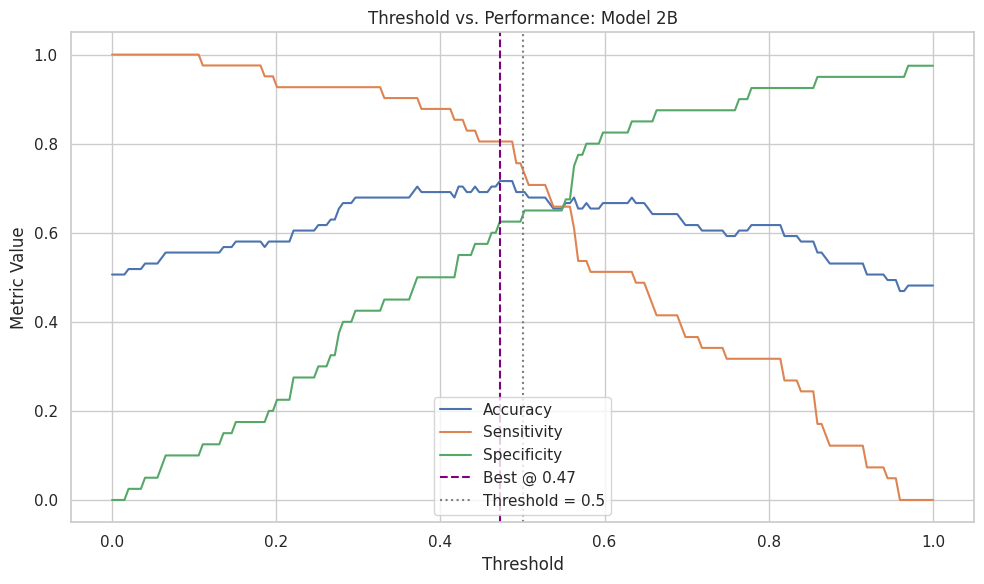


-------------- Best threshold for Model 2B --------------
Threshold: 0.47
Accuracy: 0.7160
Sensitivity: 0.8049
Specificity: 0.6250

Confusion Matrix: TP=33, TN=25, FP=15, FN=8



In [ ]:
#============================================================================================
# MODEL 2A: Train on old (60%), finetune on young (20%), test on young (20%)
#============================================================================================
base_2a = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_2a = CalibratedClassifierCV(estimator=base_2a, method='isotonic', cv=5)
model_2a.fit(pd.concat([X_train_1, X_finetune_young_1]), pd.concat([y_train_1, y_finetune_young_1]))

y_prob_2a = model_2a.predict_proba(X_test_young_1)[:, 1]
optimal_thresh_2a = plot_threshold_performance(y_test_young_1, y_prob_2a, model_label="Model 2A")

y_pred_2a = (y_prob_2a >= optimal_thresh_2a).astype(int)
tn_2a, fp_2a, fn_2a, tp_2a = confusion_matrix(y_test_young_1, y_pred_2a).ravel()

print(f"Confusion Matrix: TP={tp_2a}, TN={tn_2a}, FP={fp_2a}, FN={fn_2a}")
print()

#============================================================================================
# MODEL 2B: Train on old (60%), finetune on old (20%), test on old (20%)
#============================================================================================
base_2b = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_2b = CalibratedClassifierCV(estimator=base_2b, method='isotonic', cv=5)
model_2b.fit(pd.concat([X_train_1, X_finetune_old_1]), pd.concat([y_train_1, y_finetune_old_1]))

y_prob_2b = model_2b.predict_proba(X_test_old_1)[:, 1]
optimal_thresh_2b = plot_threshold_performance(y_test_old_1, y_prob_2b, model_label="Model 2B")

y_pred_2b = (y_prob_2b >= optimal_thresh_2b).astype(int)
tn_2b, fp_2b, fn_2b, tp_2b = confusion_matrix(y_test_old_1, y_pred_2b).ravel()

print(f"Confusion Matrix: TP={tp_2b}, TN={tn_2b}, FP={fp_2b}, FN={fn_2b}")
print()

3. Below is the code for a **Random Forest Classifier** model **trained on the entire dataset**, first independently trained on young data, then independently trained on old data.



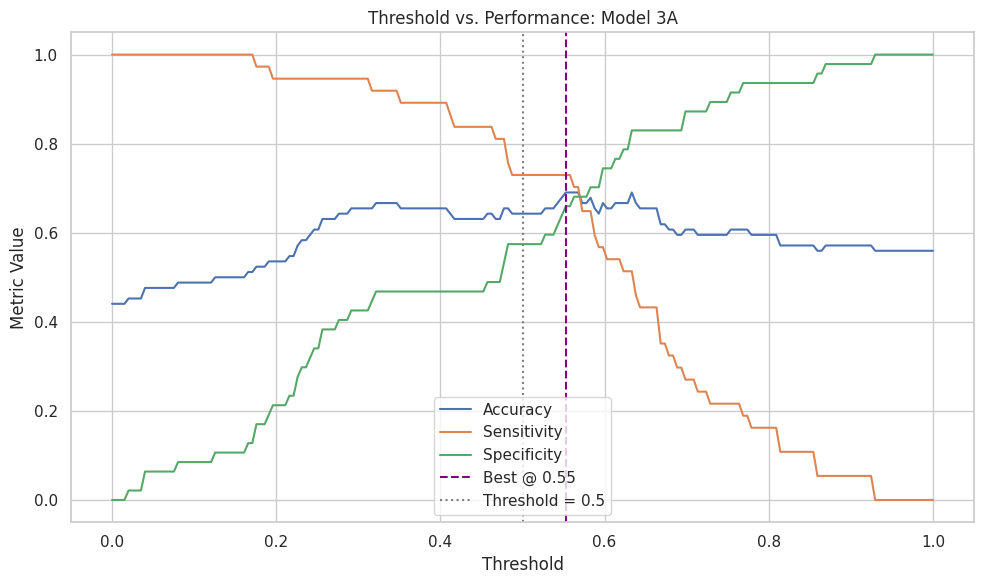


-------------- Best threshold for Model 3A --------------
Threshold: 0.55
Accuracy: 0.6905
Sensitivity: 0.7297
Specificity: 0.6596

Confusion Matrix: TP=27, TN=31, FP=16, FN=10



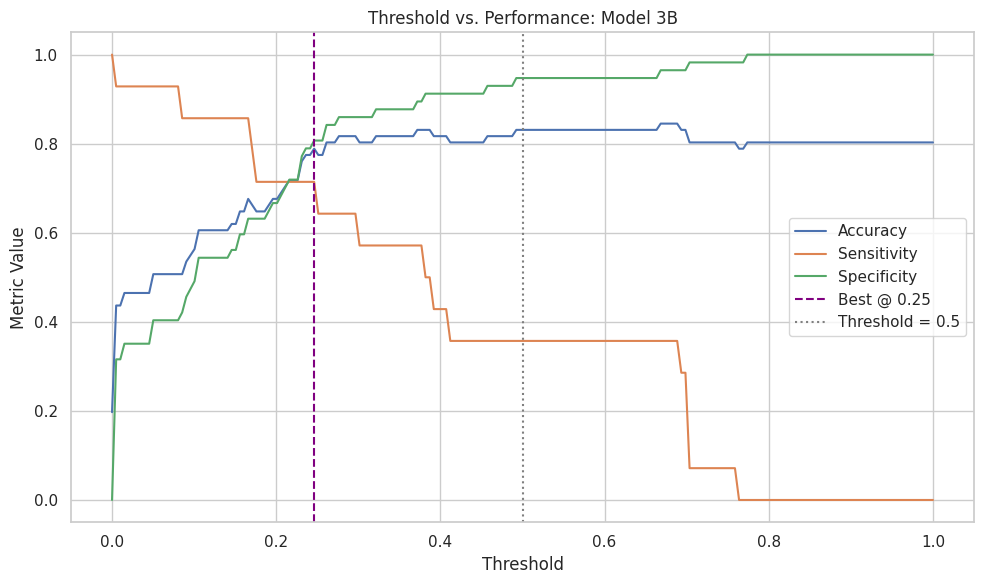


-------------- Best threshold for Model 3B --------------
Threshold: 0.25
Accuracy: 0.7887
Sensitivity: 0.7143
Specificity: 0.8070

Confusion Matrix: TP=10, TN=46, FP=11, FN=4



In [ ]:
#============================================================================================
# MODEL 3A: Train on full (60%), finetune on old (10%), test on old (10%)
#============================================================================================
base_3a = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_3a = CalibratedClassifierCV(estimator=base_3a, method='isotonic', cv=5)
model_3a.fit(pd.concat([X_train_2, X_finetune_old_2]), pd.concat([y_train_2, y_finetune_old_2]))

y_prob_3a = model_3a.predict_proba(X_test_old_2)[:, 1]
optimal_thresh_3a = plot_threshold_performance(y_test_old_2, y_prob_3a, model_label="Model 3A")

y_pred_3a = (y_prob_3a >= optimal_thresh_3a).astype(int)
tn_3a, fp_3a, fn_3a, tp_3a = confusion_matrix(y_test_old_2, y_pred_3a).ravel()

print(f"Confusion Matrix: TP={tp_3a}, TN={tn_3a}, FP={fp_3a}, FN={fn_3a}")
print()

#============================================================================================
# MODEL 3B: Train on full (60%), finetune on young (10%), test on young (10%)
#============================================================================================
base_3b = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_3b = CalibratedClassifierCV(estimator=base_3b, method='isotonic', cv=5)
model_3b.fit(pd.concat([X_train_2, X_finetune_young_2]), pd.concat([y_train_2, y_finetune_young_2]))

y_prob_3b = model_3b.predict_proba(X_test_young_2)[:, 1]
optimal_thresh_3b = plot_threshold_performance(y_test_young_2, y_prob_3b, model_label="Model 3B")

y_pred_3b = (y_prob_3b >= optimal_thresh_3b).astype(int)
tn_3b, fp_3b, fn_3b, tp_3b = confusion_matrix(y_test_young_2, y_pred_3b).ravel()

print(f"Confusion Matrix: TP={tp_3b}, TN={tn_3b}, FP={fp_3b}, FN={fn_3b}")
print()


4 - Below is the code for the creation of a **Support Vector Machine** model **trained on young data** which tests on old data and then tests on young data as a control.

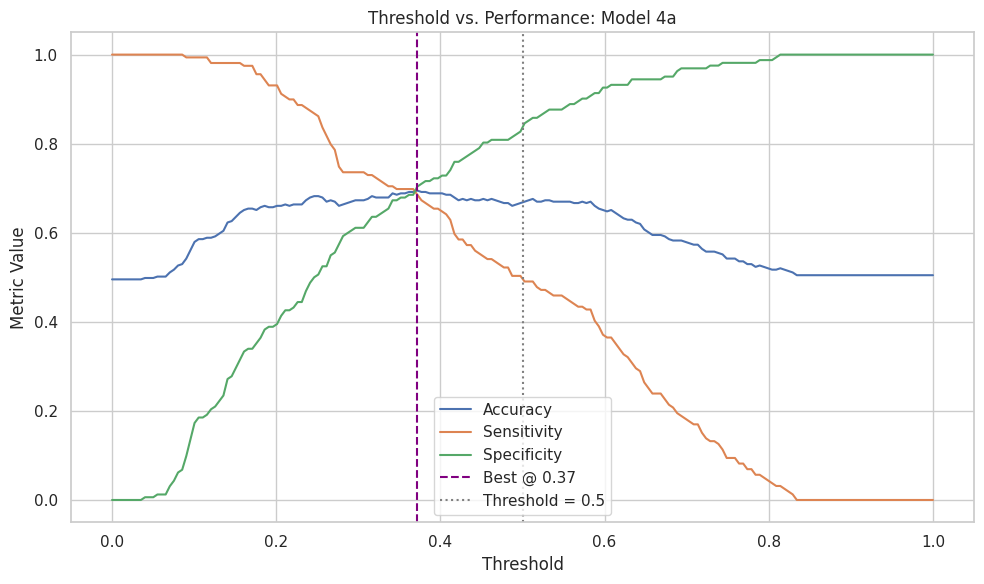


-------------- Best threshold for Model 4a --------------
Threshold: 0.37
Accuracy: 0.6947
Sensitivity: 0.6855
Specificity: 0.7037

Confusion Matrix: TP=109, TN=114, FP=48, FN=50


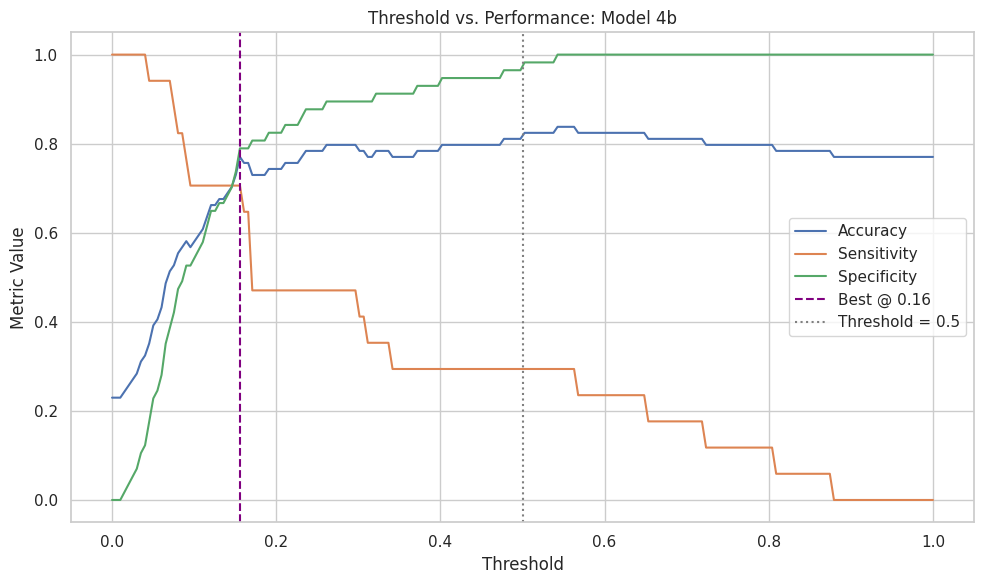


-------------- Best threshold for Model 4b --------------
Threshold: 0.16
Accuracy: 0.7703
Sensitivity: 0.7059
Specificity: 0.7895

Confusion Matrix: TP=12, TN=45, FP=12, FN=5


In [ ]:
#============================================================================================
# Model 4a: SVM - young train (60%) + old finetune (20%) → old test
#============================================================================================

model_4a = SVC(probability=True, kernel='rbf', class_weight='balanced', random_state=42)
model_4a.fit(pd.concat([X_train, X_finetune_old]), pd.concat([y_train, y_finetune_old]))

# Predict probabilities
y_prob_4a = model_4a.predict_proba(X_test_old)[:, 1]
y_true_4a = y_test_old.to_numpy()

# Determine best threshold using standardized function
best_thresh_4a = plot_threshold_performance(y_true_4a, y_prob_4a, model_label="Model 4a", metric="youden")

# Apply threshold and evaluate
y_pred_4a = (y_prob_4a >= best_thresh_4a).astype(int)
tn_4a, fp_4a, fn_4a, tp_4a = confusion_matrix(y_true_4a, y_pred_4a).ravel()
accuracy_4a = (tp_4a + tn_4a) / (tp_4a + tn_4a + fp_4a + fn_4a)
sensitivity_4a = tp_4a / (tp_4a + fn_4a)
specificity_4a = tn_4a / (tn_4a + fp_4a)

print(f"Confusion Matrix: TP={tp_4a}, TN={tn_4a}, FP={fp_4a}, FN={fn_4a}")

#============================================================================================
# Model 4b: SVM - young train (60%) + young finetune (20%) → young test
#============================================================================================

model_4b = SVC(probability=True, kernel='rbf', class_weight='balanced', random_state=42)
model_4b.fit(pd.concat([X_train, X_finetune_young]), pd.concat([y_train, y_finetune_young]))

# Predict probabilities
y_prob_4b = model_4b.predict_proba(X_test_young)[:, 1]
y_true_4b = y_test_young.to_numpy()

# Determine best threshold
best_thresh_4b = plot_threshold_performance(y_true_4b, y_prob_4b, model_label="Model 4b", metric="youden")

# Apply threshold and evaluate
y_pred_4b = (y_prob_4b >= best_thresh_4b).astype(int)
tn_4b, fp_4b, fn_4b, tp_4b = confusion_matrix(y_true_4b, y_pred_4b).ravel()
accuracy_4b = (tp_4b + tn_4b) / (tp_4b + tn_4b + fp_4b + fn_4b)
sensitivity_4b = tp_4b / (tp_4b + fn_4b)
specificity_4b = tn_4b / (tn_4b + fp_4b)

print(f"Confusion Matrix: TP={tp_4b}, TN={tn_4b}, FP={fp_4b}, FN={fn_4b}")


5. Below is the code for a **Support Vector Machine** model **trained on old data**, tested on young data, then tested as a control on old data.

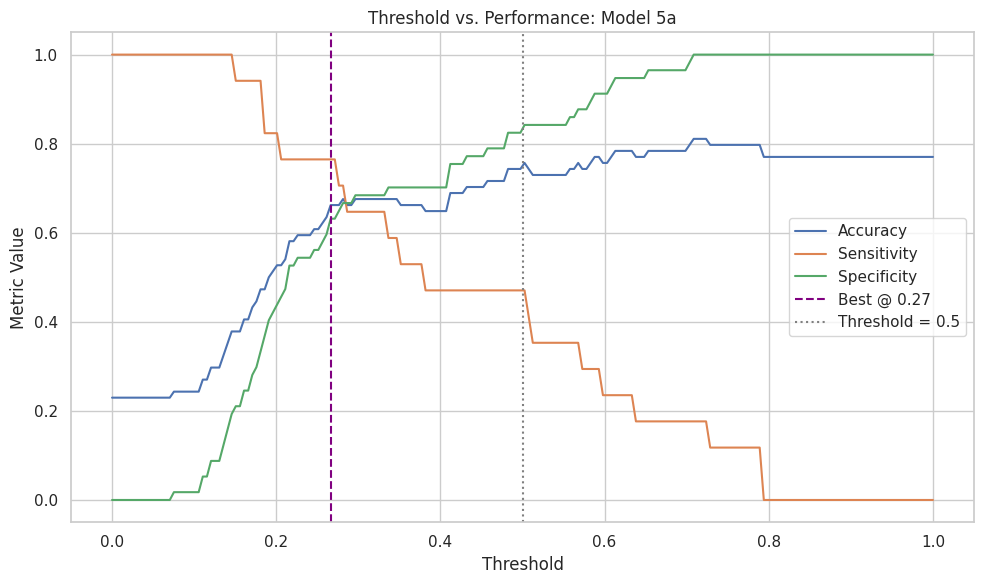


-------------- Best threshold for Model 5a --------------
Threshold: 0.27
Accuracy: 0.6622
Sensitivity: 0.7647
Specificity: 0.6316


Confusion Matrix: TP=13, TN=36, FP=21, FN=4


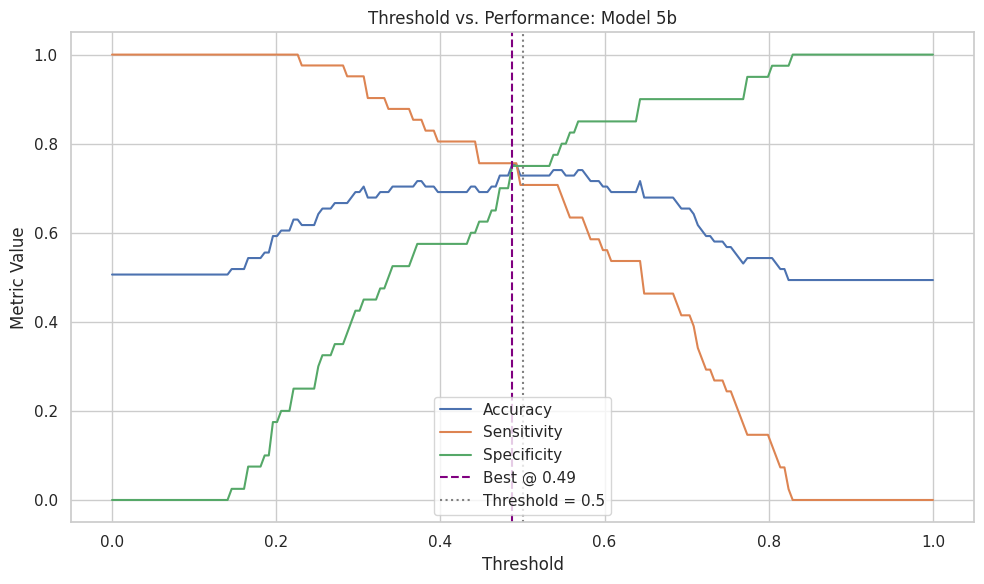


-------------- Best threshold for Model 5b --------------
Threshold: 0.49
Accuracy: 0.7531
Sensitivity: 0.7561
Specificity: 0.7500


Confusion Matrix: TP=31, TN=30, FP=10, FN=10


In [ ]:
#============================================================================================
# Model 5a: SVM - old train + young finetune → young test
#============================================================================================
model_5a = SVC(probability=True, kernel='rbf', class_weight='balanced', random_state=42)
model_5a.fit(pd.concat([X_train_1, X_finetune_young_1]), pd.concat([y_train_1, y_finetune_young_1]))

y_prob_5a = model_5a.predict_proba(X_test_young_1)[:, 1]
y_true_5a = y_test_young_1.to_numpy()

best_thresh_5a = plot_threshold_performance(y_true_5a, y_prob_5a, model_label="Model 5a", metric="youden")
y_pred_5a = (y_prob_5a >= best_thresh_5a).astype(int)

tn_5a, fp_5a, fn_5a, tp_5a = confusion_matrix(y_true_5a, y_pred_5a).ravel()
print(f"\nConfusion Matrix: TP={tp_5a}, TN={tn_5a}, FP={fp_5a}, FN={fn_5a}")

#============================================================================================
# Model 5b: SVM - old train + old finetune → old test
#============================================================================================
model_5b = SVC(probability=True, kernel='rbf', class_weight='balanced', random_state=42)
model_5b.fit(pd.concat([X_train_1, X_finetune_old_1]), pd.concat([y_train_1, y_finetune_old_1]))

y_prob_5b = model_5b.predict_proba(X_test_old_1)[:, 1]
y_true_5b = y_test_old_1.to_numpy()

best_thresh_5b = plot_threshold_performance(y_true_5b, y_prob_5b, model_label="Model 5b", metric="youden")
y_pred_5b = (y_prob_5b >= best_thresh_5b).astype(int)

tn_5b, fp_5b, fn_5b, tp_5b = confusion_matrix(y_true_5b, y_pred_5b).ravel()
print(f"\nConfusion Matrix: TP={tp_5b}, TN={tn_5b}, FP={fp_5b}, FN={fn_5b}")


6. Below is the code for a **Support Vector Machine** model **trained on the entire dataset**, first independently trained on young data, then independently trained on old data.

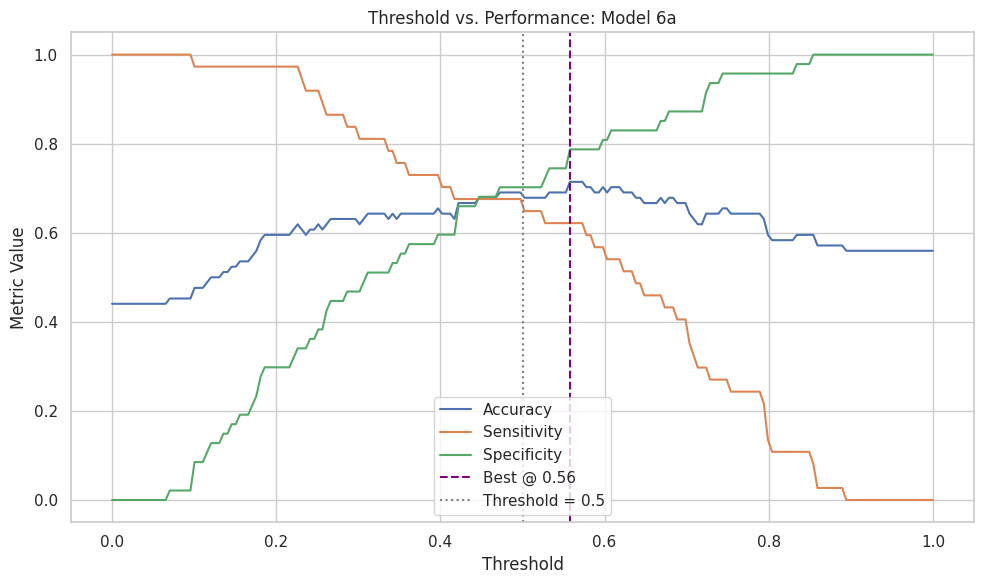


-------------- Best threshold for Model 6a --------------
Threshold: 0.56
Accuracy: 0.7143
Sensitivity: 0.6216
Specificity: 0.7872


Confusion Matrix: TP=23, TN=37, FP=10, FN=14


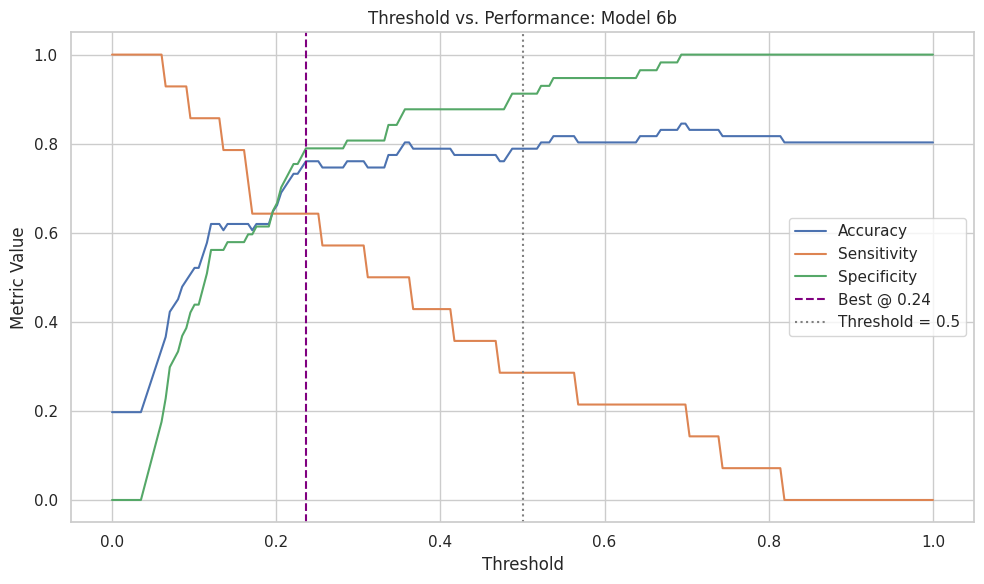


-------------- Best threshold for Model 6b --------------
Threshold: 0.24
Accuracy: 0.7606
Sensitivity: 0.6429
Specificity: 0.7895


Confusion Matrix: TP=9, TN=45, FP=12, FN=5


In [ ]:
#============================================================================================
# Model 6a: SVM - full train + old finetune → old test
#============================================================================================
model_6a = SVC(probability=True, kernel='rbf', class_weight='balanced', random_state=42)
model_6a.fit(pd.concat([X_train_2, X_finetune_old_2]), pd.concat([y_train_2, y_finetune_old_2]))

y_prob_6a = model_6a.predict_proba(X_test_old_2)[:, 1]
y_true_6a = y_test_old_2.to_numpy()

best_thresh_6a = plot_threshold_performance(y_true_6a, y_prob_6a, model_label="Model 6a", metric="youden")
y_pred_6a = (y_prob_6a >= best_thresh_6a).astype(int)

tn_6a, fp_6a, fn_6a, tp_6a = confusion_matrix(y_true_6a, y_pred_6a).ravel()
print(f"\nConfusion Matrix: TP={tp_6a}, TN={tn_6a}, FP={fp_6a}, FN={fn_6a}")

#============================================================================================
# Model 6b: SVM - full train + young finetune → young test
#============================================================================================
model_6b = SVC(probability=True, kernel='rbf', class_weight='balanced', random_state=42)
model_6b.fit(pd.concat([X_train_2, X_finetune_young_2]), pd.concat([y_train_2, y_finetune_young_2]))

y_prob_6b = model_6b.predict_proba(X_test_young_2)[:, 1]
y_true_6b = y_test_young_2.to_numpy()

best_thresh_6b = plot_threshold_performance(y_true_6b, y_prob_6b, model_label="Model 6b", metric="youden")
y_pred_6b = (y_prob_6b >= best_thresh_6b).astype(int)

tn_6b, fp_6b, fn_6b, tp_6b = confusion_matrix(y_true_6b, y_pred_6b).ravel()
print(f"\nConfusion Matrix: TP={tp_6b}, TN={tn_6b}, FP={fp_6b}, FN={fn_6b}")

# Model Performance Analysis

Below is the plotting of the performance metrics for the RFC models (1a-3b)

---- Model 1a ----
Using Provided Threshold: 0.422
Accuracy: 0.7321
Sensitivity: 0.8113
Specificity: 0.6543

---- Model 1b ----
Using Provided Threshold: 0.156
Accuracy: 0.7703
Sensitivity: 0.7647
Specificity: 0.7719

---- Model 2a ----
Using Provided Threshold: 0.367
Accuracy: 0.8243
Sensitivity: 0.4706
Specificity: 0.9298

---- Model 2b ----
Using Provided Threshold: 0.472
Accuracy: 0.7160
Sensitivity: 0.8049
Specificity: 0.6250

---- Model 3a ----
Using Provided Threshold: 0.553
Accuracy: 0.6905
Sensitivity: 0.7297
Specificity: 0.6596

---- Model 3b ----
Using Provided Threshold: 0.246
Accuracy: 0.7887
Sensitivity: 0.7143
Specificity: 0.8070



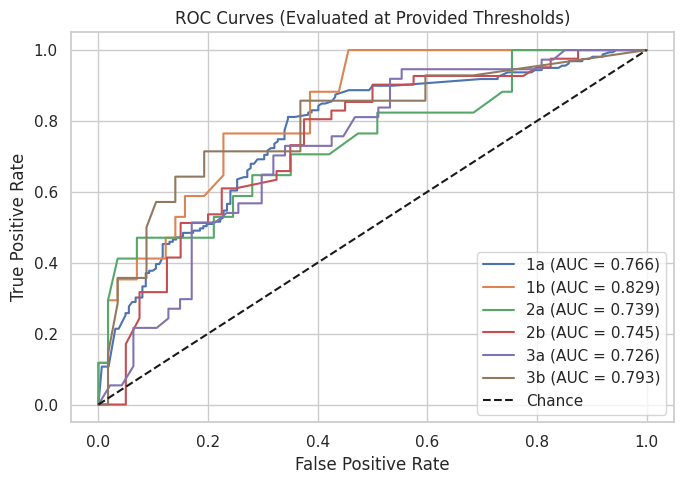

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def evaluate_models_at_fixed_thresholds(models, labels, thresholds, X_tests, y_tests):
    plt.figure(figsize=(7, 5))

    for model, label, threshold, X_test, y_test in zip(models, labels, thresholds, X_tests, y_tests):
        y_true = np.array(y_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # ROC and AUC
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.3f})')

        # Use your provided threshold
        y_pred = (y_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)

        print(f'---- Model {label} ----')
        print(f'Using Provided Threshold: {threshold:.3f}')
        print(f'Accuracy: {accuracy:.4f}')
        print(f'Sensitivity: {sensitivity:.4f}')
        print(f'Specificity: {specificity:.4f}')
        print()

    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.title('ROC Curves (Evaluated at Provided Thresholds)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example thresholds (replace with your actual values)
rfc_thresholds = [optimal_thresh_1a, optimal_thresh_1b, optimal_thresh_2a, optimal_thresh_2b, optimal_thresh_3a, optimal_thresh_3b]  # Replace with exact ones you computed

evaluate_models_at_fixed_thresholds(
    models=[model_1a, model_1b, model_2a, model_2b, model_3a, model_3b],
    labels=['1a', '1b', '2a', '2b', '3a', '3b'],
    thresholds=rfc_thresholds,
    X_tests=[X_test_old, X_test_young, X_test_young_1, X_test_old_1, X_test_old_2, X_test_young_2],
    y_tests=[y_test_old, y_test_young, y_test_young_1, y_test_old_1, y_test_old_2, y_test_young_2]
)


Below is the plotting of the performance metrics for the SVM models (4a-6b)

---- Model 4a ----
Using Provided Threshold: 0.472
Accuracy: 0.7040
Sensitivity: 0.5786
Specificity: 0.8272

---- Model 4b ----
Using Provided Threshold: 0.171
Accuracy: 0.7703
Sensitivity: 0.5882
Specificity: 0.8246

---- Model 5a ----
Using Provided Threshold: 0.271
Accuracy: 0.7027
Sensitivity: 0.7647
Specificity: 0.6842

---- Model 5b ----
Using Provided Threshold: 0.503
Accuracy: 0.7407
Sensitivity: 0.7073
Specificity: 0.7750

---- Model 6a ----
Using Provided Threshold: 0.533
Accuracy: 0.7143
Sensitivity: 0.6486
Specificity: 0.7660

---- Model 6b ----
Using Provided Threshold: 0.291
Accuracy: 0.7746
Sensitivity: 0.6429
Specificity: 0.8070



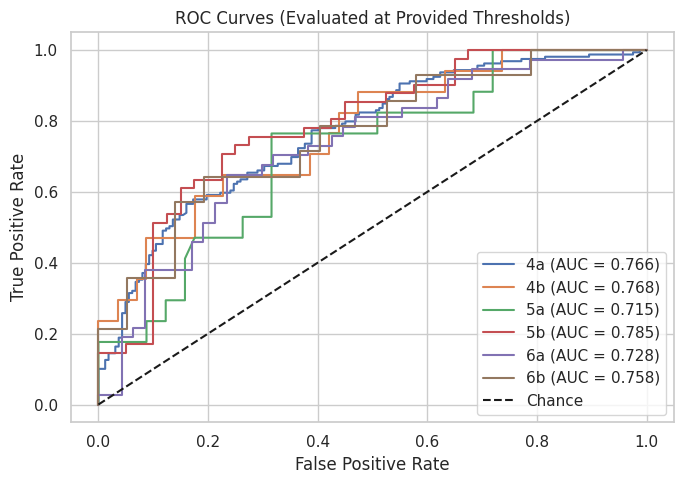

In [ ]:
# ==== Evaluate SVM Models 4a–6b at Fixed Thresholds ====

svm_models = [model_4a, model_4b, model_5a, model_5b, model_6a, model_6b]
svm_labels = ['4a', '4b', '5a', '5b', '6a', '6b']
svm_thresholds = [best_thresh_4a, best_thresh_4b, best_thresh_5a, best_thresh_5b, best_thresh_6a, best_thresh_6b]

X_svm_tests = [X_test_old, X_test_young, X_test_young_1, X_test_old_1, X_test_old_2, X_test_young_2]
y_svm_tests = [y_test_old, y_test_young, y_test_young_1, y_test_old_1, y_test_old_2, y_test_young_2]

evaluate_models_at_fixed_thresholds(
    models=svm_models,
    labels=svm_labels,
    thresholds=svm_thresholds,
    X_tests=X_svm_tests,
    y_tests=y_svm_tests
)
